In [ ]:
%pip install scipy matplotlib numpy pandas scikit-learn xgboost

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.1 MB 16.8 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 18.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 16.8 MB/s  0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -------------------- ------------------- 5.0/9.7 MB 25.2 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.7 MB 19.4 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.7 MB 15.1 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 13.5 MB/s  0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.0 MB 9.3 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.0 MB 9.9 MB/s eta 0:00:01
   ------------------------------- -------- 

In [ ]:
%pip install scipy


In [8]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [9]:
file_path = r"C:\Users\admin\Desktop\PPG_Diabetes_Project\data\raw\signal_01_0001.mat"
mat_data = scipy.io.loadmat(file_path)
print("Here is what is inside the file:")
print(mat_data.keys())

Here is what is inside the file:
dict_keys(['__header__', '__version__', '__globals__', 'signal'])


Shape of the signal array: (21900, 1)


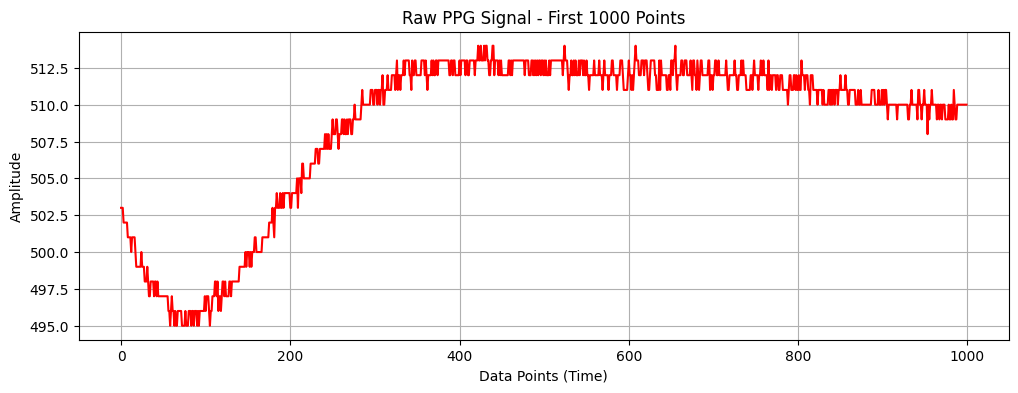

In [10]:
# 1. Extract the data array using the key we found
signal_array = mat_data['signal']

# 2. Print the shape so we know exactly how much data is in this file
print("Shape of the signal array:", signal_array.shape)

# 3. Plot the first 1000 data points (which is a few seconds of a heartbeat)
plt.figure(figsize=(12, 4))

# Medical datasets format their arrays differently (sometimes rows, sometimes columns)
# This code checks the shape and plots the first channel correctly
if signal_array.ndim > 1:
    if signal_array.shape[0] > signal_array.shape[1]:
        plt.plot(signal_array[:1000, 0], color='red') # Takes the first column
    else:
        plt.plot(signal_array[0, :1000], color='red') # Takes the first row
else:
    plt.plot(signal_array[:1000], color='red') # Simple 1D array

plt.title('Raw PPG Signal - First 1000 Points')
plt.xlabel('Data Points (Time)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

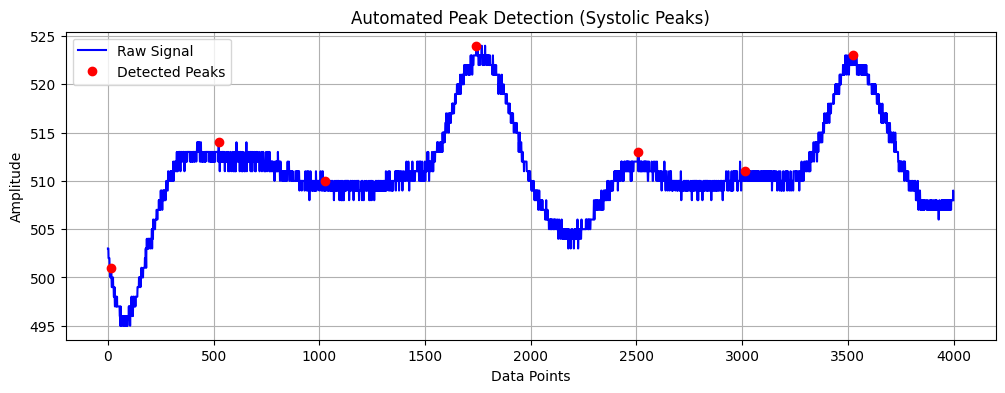

Total peaks found in file: 30
Estimated Heart Rate: 79.53 BPM


In [11]:
from scipy.signal import find_peaks
import numpy as np

# 1. Flatten the array so it's a simple 1D list instead of a 2D column
clean_signal = signal_array.flatten()

# 2. Define the Sampling Rate (Hz)
# Mendeley datasets usually use high frequency like 1000 Hz or 2175 Hz. 
# We'll assume 1000 for now (meaning 21,900 points = ~21.9 seconds of data)
fs = 1000 

# 3. Find the peaks!
# 'distance=fs/2' means we expect at least half a second between heartbeats (max 120 BPM)
peaks, properties = find_peaks(clean_signal, distance=fs/2)

# 4. Plot a small section to verify the math is working
plt.figure(figsize=(12, 4))

# Plot the first 4000 points of the signal
plt.plot(clean_signal[:4000], color='blue', label='Raw Signal')

# Filter our 'peaks' array to only show the ones that happen in the first 4000 points
visible_peaks = [p for p in peaks if p < 4000]

# Put a red dot on every peak we found
plt.plot(visible_peaks, clean_signal[visible_peaks], "ro", label='Detected Peaks')

plt.title('Automated Peak Detection (Systolic Peaks)')
plt.xlabel('Data Points')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# 5. Calculate some basic features to see our progress!
rr_intervals = np.diff(peaks) / fs  # Time between peaks in seconds
heart_rate = 60 / np.mean(rr_intervals) # Convert to Beats Per Minute (BPM)

print(f"Total peaks found in file: {len(peaks)}")
print(f"Estimated Heart Rate: {heart_rate:.2f} BPM")

In [14]:
import scipy.io

# 1. Define the path to ONE of your label files
# (Make sure this matches the exact file name and path in your folder!)
label_path = r"C:\Users\admin\Desktop\PPG_Diabetes_Project\data\raw\label_01_0001.mat"

# 2. Load the MATLAB file
label_data = scipy.io.loadmat(label_path)

# 3. Print the hidden keys
print("Here are the keys inside the label file:")
print(label_data.keys())

Here are the keys inside the label file:
dict_keys(['__header__', '__version__', '__globals__', 'None', '__function_workspace__'])


In [15]:
# Extract whatever is hiding inside the 'None' key
hidden_data = label_data['None']

print("Here is the actual data inside 'None':")
print(hidden_data)


Here is the actual data inside 'None':
[(b'T_temp', b'MCOS', b'table', array([[3707764736],
        [         2],
        [         1],
        [         1],
        [         1],
        [         1]], dtype=uint32))               ]


In [17]:
import pandas as pd

# 1. Load your new Kaggle dataset
# Make sure 'clean-data.csv' matches the exact name of the file you downloaded!
csv_path = r"C:\Users\admin\Desktop\PPG_Diabetes_Project\data\raw\clean-dataset.csv"
df = pd.read_csv(csv_path)

# 2. Print the column names
print("Here are the columns available for training:")
print(df.columns.tolist())

# 3. Look at the first 5 rows
display(df.head())

Here are the columns available for training:
['PPG_Signal', 'Patient_Id', 'Heart_Rate', 'Systolic_Peak', 'Diastolic_Peak', 'Pulse_Area', 'index', 'Gender', 'Age', 'Glucose_level', 'Height', 'Weight', 'pl']


,PPG_Signal,Patient_Id,Heart_Rate,Systolic_Peak,Diastolic_Peak,Pulse_Area,index,Gender,Age,Glucose_level,Height,Weight,pl
0,511,1,77.0,522.0,505.0,393.0,0,1,38,99,180,53,1
1,511,1,77.0,522.0,505.0,393.0,1,1,38,102,180,53,2
2,511,1,77.0,522.0,505.0,393.0,2,1,38,103,180,53,3
3,511,1,77.0,522.0,505.0,393.0,3,1,38,128,180,53,4
4,511,1,77.0,522.0,505.0,393.0,4,1,38,130,180,53,5
